## ARGO profiles near OOI Irminger Sea Profiler

This is a quick script to show how to find Argo profiles near the OOI Irminger Sea Hybrid Profiler Mooring [GI02HYPM](https://oceanobservatories.org/site/gi02hypm/).  In addtion to the mooring, the OOI program also has CTD Cruise Data available via BCO-DMO ERDDAP [example data](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.graph?longitude%2Clatitude%2C&latitude%3E58&latitude%3C61&longitude%3E-43&longitude%3C-37&.draw=markers&.marker=5%7C5&.color=0x000000&.colorBar=%7C%7C%7C%7C%7C&.bgColor=0xffccccff) 

Target bounding box: 59.5 to 60.5 N, 40 to 39 W

**A few helpful argopy References**
* [Fetching ARGO Data](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/index.html)
* [ARGO Index Store](https://argopy.readthedocs.io/en/latest/advanced-tools/stores/argoindex.html)
* [Aargopy Cheat Sheet](https://argopy.readthedocs.io/en/latest/cheatsheet.html)
* [Working with ARGO Index](https://github.com/euroargodev/argopy-training/blob/main/content/argo-index-meta-data/working-with-argo-index.ipynb)

In [1]:
from argopy import DataFetcher

# Setup DataFetcher to query data for a given space/time region
f = DataFetcher().region([-40, -39, 59.5, 60.5, 0, 1000, '2018-01-01', '2021-12-31'])

(<Figure size 900x540 with 1 Axes>,
 <Axes: xlabel='longitude', ylabel='latitude'>)

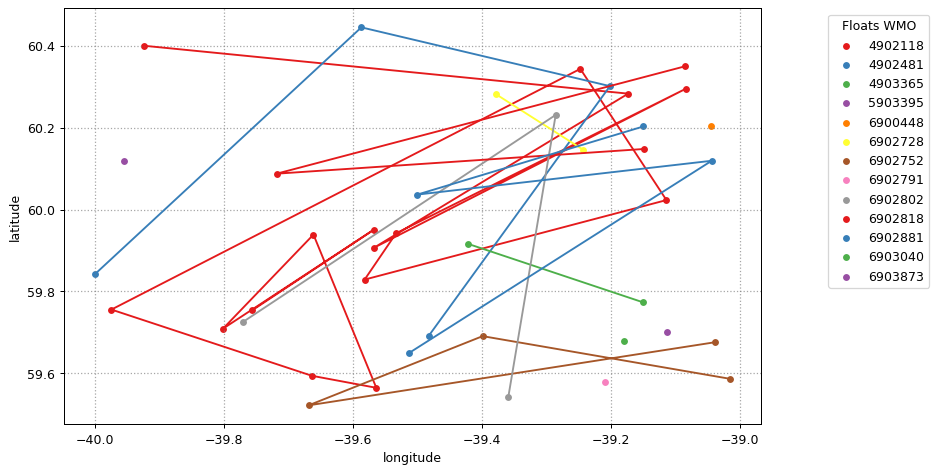

In [2]:
# The DataFetcher method has a quick method to plot profile trajectories 
f.plot('trajectory')

The DataFetcher method does not load the data, it just creates an index.  There are a number of ways we can load either the full dataset or just the index into memory, but depending on how much data you have, it could take quite a while.

Note that `DataFetcher.to_xarray()` and `DataFetcher.to_index()` will force data download on every call, while the `DataFetcher.load()` method will keep data in memory in the `DataFetcher.data` and `DataFetcher.index` properties.  [reference](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/index.html) 

In [3]:
%%time
# Load the data into an xarray Dataset.  This can take a long time if you request a lot of data.
ds_data = f.data
ds_data

CPU times: user 667 μs, sys: 1 μs, total: 668 μs
Wall time: 672 μs


<xarray.Dataset> Size: 2MB
Dimensions:          (N_POINTS: 18685)
Coordinates:
    LATITUDE         (N_POINTS) float64 149kB 60.2 60.2 60.2 ... 59.84 59.84
    LONGITUDE        (N_POINTS) float64 149kB -39.05 -39.05 ... -40.0 -40.0
    TIME             (N_POINTS) datetime64[ns] 149kB 2018-05-30T21:10:55 ... ...
  * N_POINTS         (N_POINTS) int64 149kB 0 1 2 3 ... 18681 18682 18683 18684
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 149kB 257 257 257 257 257 ... 82 82 82 82
    DATA_MODE        (N_POINTS) <U1 75kB 'D' 'D' 'D' 'D' 'D' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 75kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 149kB 6900448 6900448 ... 4902481 4902481
    POSITION_QC      (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 75kB 24.9 30.5 35.7 ... 993.3 998.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 75kB 0.01 0.01 0.01 0.01 ... nan nan nan
    PSAL_QC          (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 75kB 4.57 4.546 4.538 ... 3.425 3.424
    TEMP_ERROR       (N_POINTS) float32 75kB 0.002 0.002 0.002 ... nan nan nan
    TEMP_QC          (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           sage
    Fetched_date:         2026/02/24
    Fetched_constraints:  [x=-40.00/-39.00; y=59.50/60.50; z=0.0/1000.0; t=20...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [4]:
%%time 
# We can also load just the index into a pandas DataFrame, which is much faster.
ds_index = f.index
ds_index.head()

CPU times: user 738 μs, sys: 15 μs, total: 753 μs
Wall time: 757 μs


,date,latitude,longitude,wmo,cyc
0,2018-08-27 03:10:09,60.39997,-39.92354,4902118,82
1,2018-10-15 19:30:07,60.28311,-39.17325,4902118,87
2,2018-10-25 18:04:08,59.90653,-39.56790,4902118,88
3,2018-11-24 13:43:47,60.29484,-39.08417,4902118,91
4,2018-12-04 12:11:38,59.94224,-39.53314,4902118,92


By default, the dataset is returned as a 1D point dataset.  We can also convert it to a 2D array of vertical profiles.

In [5]:
# Convert points to profiles
ds_profiles = ds_data.argo.point2profile()
ds_profiles

<xarray.Dataset> Size: 589kB
Dimensions:          (N_PROF: 42, N_LEVELS: 690)
Coordinates:
  * N_PROF           (N_PROF) int64 336B 22 21 0 1 2 3 4 ... 16 29 19 17 20 18
  * N_LEVELS         (N_LEVELS) int64 6kB 0 1 2 3 4 5 ... 685 686 687 688 689
    LATITUDE         (N_PROF) float64 336B 60.2 60.12 60.4 ... 60.44 59.77 59.84
    LONGITUDE        (N_PROF) float64 336B -39.05 -39.96 -39.92 ... -39.15 -40.0
    TIME             (N_PROF) datetime64[ns] 336B 2018-05-30T21:10:55 ... 202...
Data variables: (12/15)
    CYCLE_NUMBER     (N_PROF) int64 336B 257 267 82 87 88 91 ... 101 1 80 2 82
    DATA_MODE        (N_PROF) <U1 168B 'D' 'D' 'D' 'D' 'D' ... 'D' 'R' 'D' 'R'
    DIRECTION        (N_PROF) <U1 168B 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_PROF) int64 336B 6900448 5903395 ... 4903365 4902481
    POSITION_QC      (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    PRES             (N_PROF, N_LEVELS) float32 116kB 24.9 30.5 35.7 ... nan nan
    ...               ...
    PSAL_ERROR       (N_PROF, N_LEVELS) float32 116kB 0.01 0.01 0.01 ... nan nan
    PSAL_QC          (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    TEMP             (N_PROF, N_LEVELS) float32 116kB 4.57 4.546 ... nan nan
    TEMP_ERROR       (N_PROF) float32 168B 0.002 0.002 0.002 ... nan 0.002 nan
    TEMP_QC          (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    TIME_QC          (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           sage
    Fetched_date:         2026/02/24
    Fetched_constraints:  [x=-40.00/-39.00; y=59.50/60.50; z=0.0/1000.0; t=20...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

Now that we have the data loaded, argopy provides a nice set of methods to interpolate data to common pressure levels or to group the data in pressure bins [see here](https://argopy.readthedocs.io/en/latest/user-guide/working-with-argo-data/data_manipulation.html).  It also has menthods for calculating [optional variables](https://argopy.readthedocs.io/en/latest/user-guide/working-with-argo-data/data_computation.html).  But we'll skip that for now.

## Plotting the Results

In [25]:
import matplotlib.pyplot as plt

year
2018     9
2019    11
2020     9
2021    13
Name: count, dtype: int64


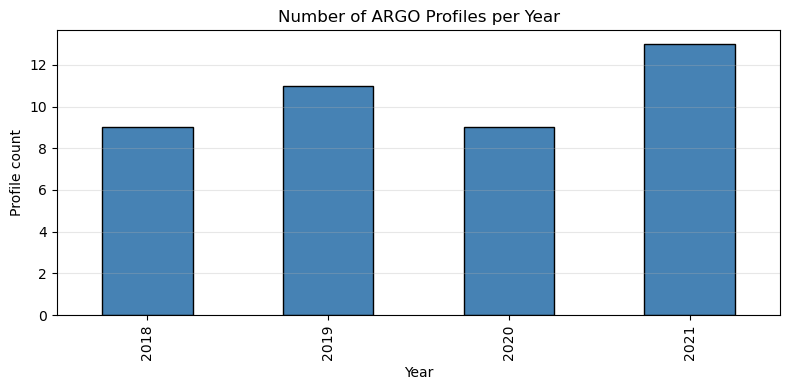

In [24]:
# Count profiles per year
profiles_per_year = (
    ds_profiles["TIME"]
    .dt.year
    .to_series()
    .value_counts()
    .sort_index()
)

print(profiles_per_year)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
profiles_per_year.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Number of ARGO Profiles per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Profile count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

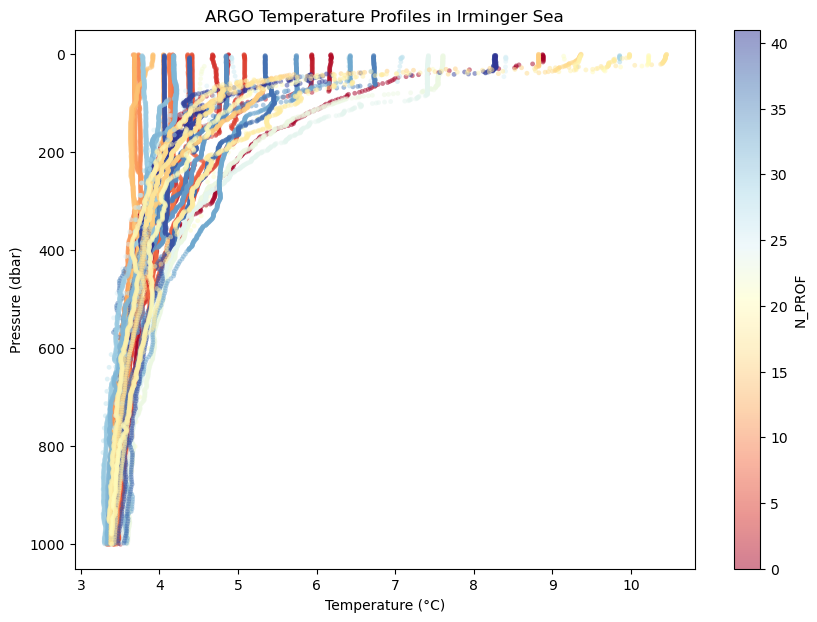

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
ds_profiles.plot.scatter(x='TEMP', y='PRES', hue='N_PROF',
    ax=ax, yincrease=False, cmap='RdYlBu',
    marker='o', s=12, alpha=.5, edgecolors='none', linewidths=0.25,
)
ax.set_title('ARGO Temperature Profiles in Irminger Sea')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Pressure (dbar)')
plt.show()

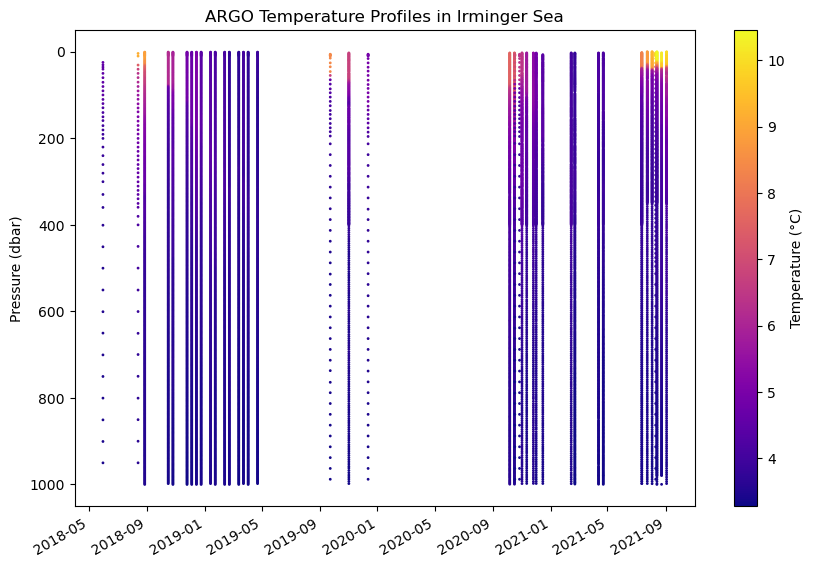

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(x=ds_data['TIME'], y=ds_data['PRES'], c=ds_data['TEMP'], s=1, cmap='plasma')
fig.colorbar(sc, ax=ax, label='Temperature (°C)')

ax.set_title('ARGO Temperature Profiles in Irminger Sea')
ax.set_ylabel('Pressure (dbar)')
ax.invert_yaxis()
fig.autofmt_xdate()
plt.show()

## ARGO Index
The method above, which loads the profile data directly can take a long time.  If you know you have a lot of profiles, it might be useful to query the Argo Index first to find those you are most interested in.

In [8]:
from argopy import ArgoIndex
idx = ArgoIndex()
idx.load()
idx.N_RECORDS

3299062

In [9]:
# Irminger Sea Area
# box = [-42, -37, 58, 61, '2018-01-01', '2021-12-31']
box = [-40, -39, 59.5, 60.5, '2018-01-01', '2021-12-31']
idx.query.box(box)
idx.N_MATCH

53

/Users/sage/miniconda3/envs/embark/lib/python3.14/site-packages/argopy/stores/index/implementations/plot.py:102: FutureWarning: Note that the long name for institution is now in 'institution_name' while the 'institution' column will hold the institution code -- Deprecated since version 1.4
  self._obj.to_dataframe(index=index), **{**default_opts, **kwargs}


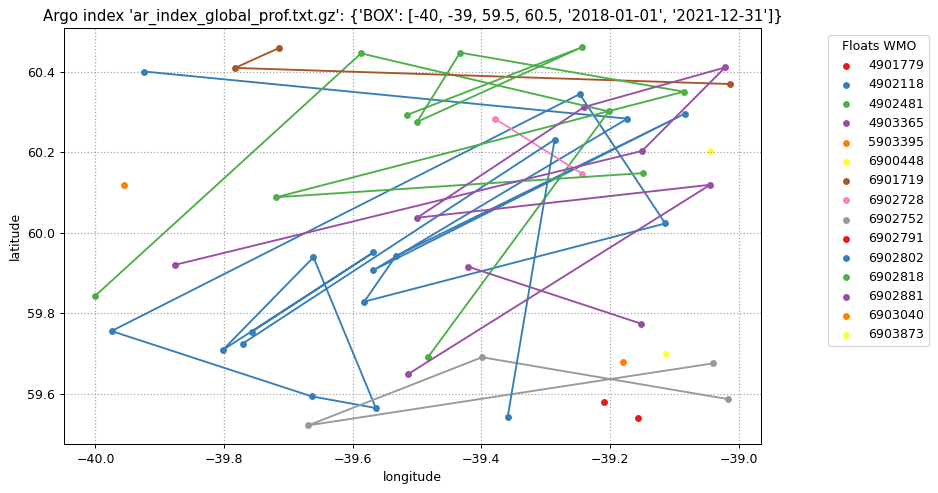

In [10]:
idx.plot.trajectory();

In [11]:
# The following functions will return a unique list of values for the given column in the index.  
print('WMO IDs %s' % idx.read_wmo())
# idx.read_dac_wmo()
# idx.read_params()
# idx.read_domain()
# idx.records_per_wmo()
# idx.uri
# idx.read_files()

WMO IDs [4901779 4902118 4902481 4903365 5903395 6900448 6901719 6902728 6902752
 6902791 6902802 6902818 6902881 6903040 6903873]
